# **Drive Mount**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Dataset Path Set**

In [ ]:
import os
dataset_path = '/content/drive/MyDrive/ChiliDoc_Dataset'
print(os.listdir(dataset_path))

['Nutrition_Deficiency', 'Cercospora_Leaf_Spot', 'Bacterial_Spot', 'Healthy_Leaf', 'Curl_Virus', 'White_Spot']


# **Libraries Import**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2 #image preprocessing

# **Data Exploration (Class Count + Sample Images)**

In [ ]:
classes = sorted([d for d in os.listdir(dataset_path)
                   if os.path.isdir(os.path.join(dataset_path, d))])
print("Classes:", classes)

for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    count = len(os.listdir(cls_path))
    print(f"{cls}: {count} images")

Classes: ['Bacterial_Spot', 'Cercospora_Leaf_Spot', 'Curl_Virus', 'Healthy_Leaf', 'Nutrition_Deficiency', 'White_Spot']
Bacterial_Spot: 156 images
Cercospora_Leaf_Spot: 180 images
Curl_Virus: 423 images
Healthy_Leaf: 458 images
Nutrition_Deficiency: 195 images
White_Spot: 195 images


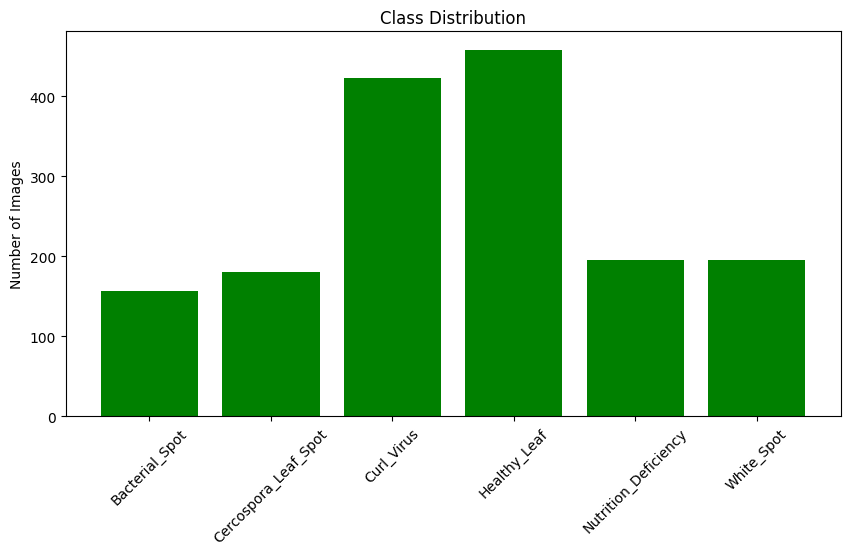

In [ ]:
# Class distribution bar chart
counts = [len(os.listdir(os.path.join(dataset_path, cls))) for cls in classes]
plt.figure(figsize=(10,5))
plt.bar(classes, counts, color='green')
plt.xticks(rotation=45)
plt.ylabel('Number of Images')
plt.title('Class Distribution')
plt.show()

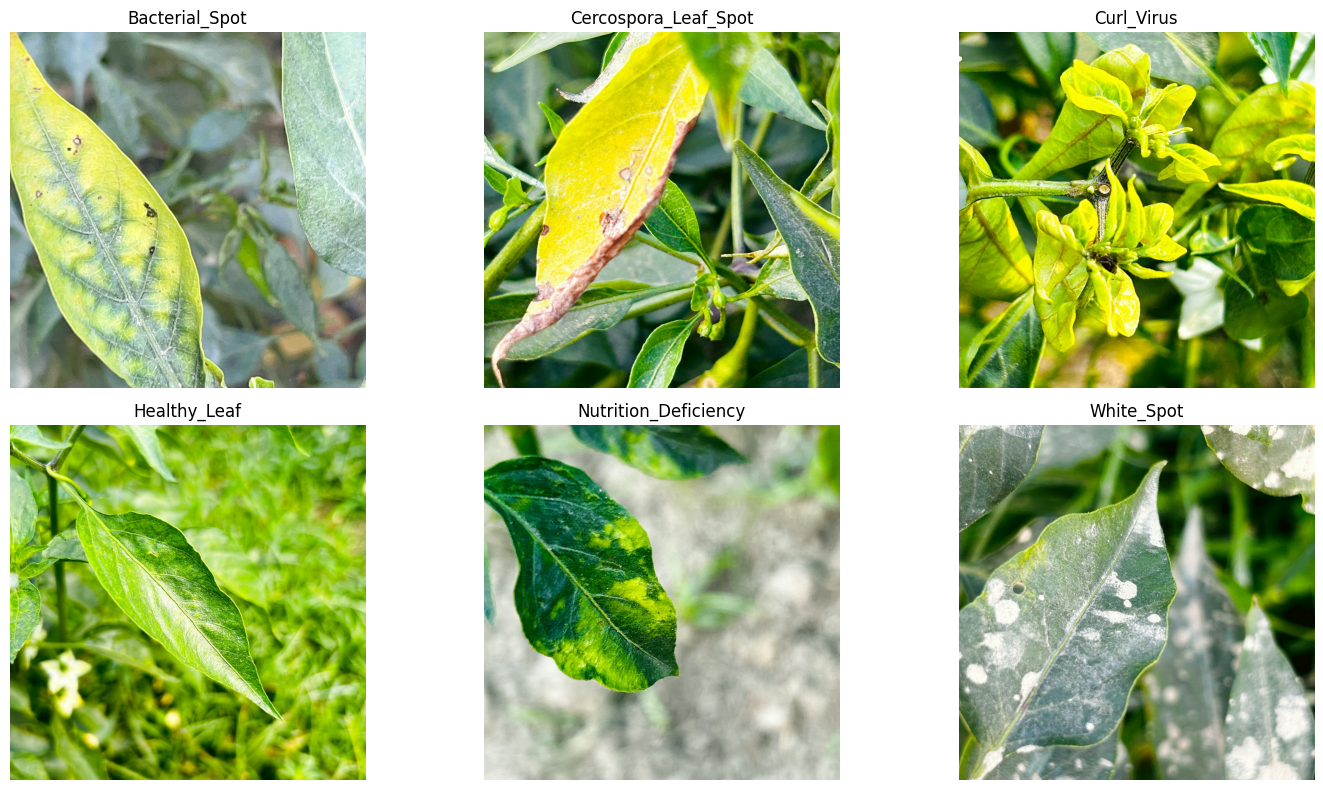

In [ ]:
# Sample images plot
plt.figure(figsize=(15,8))
for i, cls in enumerate(classes): #loop ekedi index ekai valui ekai dekama ekpara gnna
    cls_path = os.path.join(dataset_path, cls)
    sample_img = os.listdir(cls_path)[0]
    img = Image.open(os.path.join(cls_path, sample_img))
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')
plt.tight_layout()
plt.show()

# **Preprocessing Function (Resize + Normalize)**

In [ ]:
img_size = 224

def load_and_preprocess(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))
    img = img / 255.0  # normalize
    return img

# **Process each image and store them in arrays**

In [ ]:
X = []
y = []

for idx, cls in enumerate(classes):
    cls_path = os.path.join(dataset_path, cls)
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        try:
            img = load_and_preprocess(img_path)
            X.append(img)
            y.append(idx)
        except Exception as e:
            print(f"Skipped {img_path}: {e}")

X = np.array(X)
y = np.array(y)
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1607, 224, 224, 3)
y shape: (1607,)


# **Train/Validation/Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (1124, 224, 224, 3) Val: (241, 224, 224, 3) Test: (242, 224, 224, 3)


# **Processed Data Save**

In [ ]:
save_path = '/content/drive/MyDrive/ChiliDoc_Processed'
os.makedirs(save_path, exist_ok=True)

np.save(os.path.join(save_path, 'X_train.npy'), X_train)
np.save(os.path.join(save_path, 'y_train.npy'), y_train)
np.save(os.path.join(save_path, 'X_val.npy'), X_val)
np.save(os.path.join(save_path, 'y_val.npy'), y_val)
np.save(os.path.join(save_path, 'X_test.npy'), X_test)
np.save(os.path.join(save_path, 'y_test.npy'), y_test)

print("Processed data saved!")

Processed data saved!


# **Load from the CNN/ViT notebooks**

In [ ]:
import numpy as np

save_path = '/content/drive/MyDrive/ChiliDoc_Processed'
X_train = np.load(os.path.join(save_path, 'X_train.npy'))
y_train = np.load(os.path.join(save_path, 'y_train.npy'))
X_val = np.load(os.path.join(save_path, 'X_val.npy'))
y_val = np.load(os.path.join(save_path, 'y_val.npy'))

NameError: name 'os' is not defined